<a href="https://colab.research.google.com/github/akshitamaddela16/M.Akshitha/blob/main/TNS_Association.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Sample transaction data
transactions = [
    ['Milk', 'Bread', 'Butter'],
    ['Milk', 'Bread'],
    ['Milk', 'Butter'],
    ['Bread', 'Butter'],
    ['Milk', 'Bread', 'Butter'],
    ['Milk', 'Eggs'],
    ['Bread', 'Eggs'],
    ['Milk', 'Bread', 'Eggs']
]

# Convert transactions to one-hot encoded format
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_array, columns=te.columns_)

print("Transaction Data:\n")
print(df)

# Find frequent itemsets
frequent_itemsets = apriori(df,
                            min_support=0.3,
                            use_colnames=True)

print("\nFrequent Itemsets:\n")
print(frequent_itemsets)

# Generate association rules
rules = association_rules(frequent_itemsets,
                          metric="confidence",
                          min_threshold=0.6)

print("\nAssociation Rules:\n")
print(rules[['antecedents',
             'consequents',
             'support',
             'confidence',
             'lift']])

Transaction Data:

   Bread  Butter   Eggs   Milk
0   True    True  False   True
1   True   False  False   True
2  False    True  False   True
3   True    True  False  False
4   True    True  False   True
5  False   False   True   True
6   True   False   True  False
7   True   False   True   True

Frequent Itemsets:

   support         itemsets
0    0.750          (Bread)
1    0.500         (Butter)
2    0.375           (Eggs)
3    0.750           (Milk)
4    0.375  (Bread, Butter)
5    0.500    (Bread, Milk)
6    0.375   (Milk, Butter)

Association Rules:

  antecedents consequents  support  confidence      lift
0    (Butter)     (Bread)    0.375    0.750000  1.000000
1     (Bread)      (Milk)    0.500    0.666667  0.888889
2      (Milk)     (Bread)    0.500    0.666667  0.888889
3    (Butter)      (Milk)    0.375    0.750000  1.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

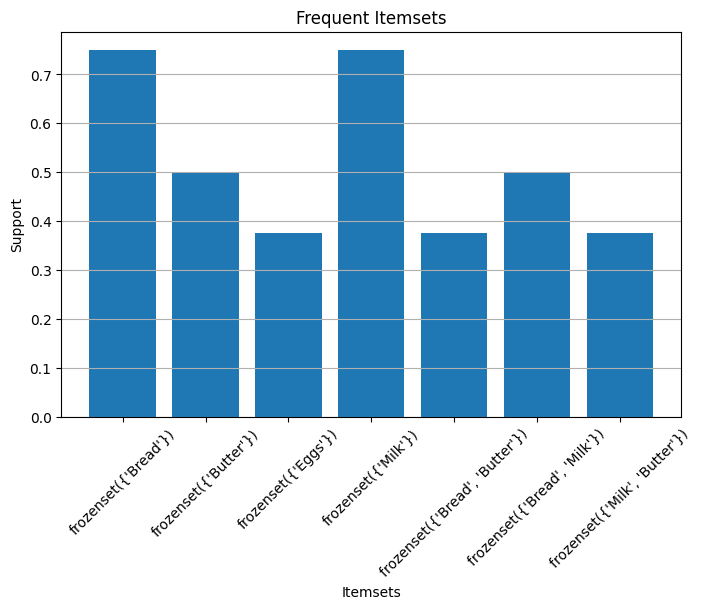

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt

# Convert itemsets to strings
frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].astype(str)

# Plot
plt.figure(figsize=(8,5))
plt.bar(frequent_itemsets['itemsets'],
        frequent_itemsets['support'])

plt.title("Frequent Itemsets")
plt.xlabel("Itemsets")
plt.ylabel("Support")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()